## Elderly Healthcare Access Analysis: Health Spending vs. Life Expectancy in East Africa

**Author:** Sandra Kayirangwa

### Overview
This analysis explores whether higher per-capita health spending is associated with 
longer life expectancy across five East African countries: Rwanda, Kenya, Uganda, 
Tanzania, and Burundi. The goal is to identify patterns in healthcare investment and 
outcomes that may point to gaps in elderly healthcare access in the region.

## Research Question
Does higher current health expenditure per capita predict longer life expectancy 
at birth among East African countries?

## Data Sources
- **Current Health Expenditure per Capita (current US$)** — World Bank Open Data 
  (indicator: SH.XPD.CHEX.PC.CD)
- **Life Expectancy at Birth, Total (years)** — World Bank Open Data 
  (indicator: SP.DYN.LE00.IN)

Data covers: Rwanda, Kenya, Uganda, Tanzania, Burundi.

In [6]:
import pandas as pd

health = pd.read_csv('stats/health_expenditure.csv')
life_exp = pd.read_csv('stats/life_expectancy.csv')

health.head()
life_exp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Rwanda,RWA,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,47.022,47.458,47.802,43.998,48.131,48.203,...,65.733,66.140,66.354,66.691,66.953,66.850,67.528,67.785,68.017,NaN
1,Kenya,KEN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,48.477,49.330,50.104,50.758,51.323,51.886,...,62.526,62.725,62.825,62.939,61.596,61.225,63.549,63.646,63.834,NaN
2,Uganda,UGA,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,45.633,46.271,46.821,47.378,47.846,48.303,...,64.494,65.174,65.775,66.354,66.410,66.450,67.675,68.252,68.487,NaN
3,Burundi,BDI,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,43.262,43.364,43.492,43.559,43.601,41.844,...,60.789,61.345,61.806,62.180,62.569,62.101,62.882,63.651,63.818,NaN
4,Tanzania,TZA,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,42.596,42.841,43.215,43.616,44.075,44.542,...,64.404,64.963,65.488,66.007,66.771,66.131,66.879,66.995,67.212,NaN


In [7]:
health.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Rwanda,RWA,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,43.542122,40.766827,42.116749,39.813221,45.152664,51.646774,57.831020,52.656307,NaN,NaN
1,Kenya,KEN,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,73.887680,66.465523,75.276817,85.645287,86.592194,94.202492,91.184166,84.958992,NaN,NaN
2,Uganda,UGA,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,39.081253,31.438181,32.951569,33.365597,44.733818,51.034847,44.472862,45.213184,NaN,NaN
3,Burundi,BDI,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,18.594728,19.166765,18.678192,22.243538,26.219343,23.114201,25.521551,28.140289,NaN,NaN
4,Tanzania,TZA,Current health expenditure per capita (current...,SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,36.652676,39.037670,41.271713,39.977837,31.703617,37.531212,35.933231,36.256199,NaN,NaN


In [10]:
year_cols = [str(y) for y in range(2000, 2023)]

health_long = health.melt(
    id_vars=["Country Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="HealthSpending"
)

life_long = life_exp.melt(
    id_vars=["Country Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="LifeExpectancy"
)

merged = pd.merge(health_long, life_long, on=["Country Name", "Year"])
merged = merged.dropna()

merged.head(10)

,Country Name,Year,HealthSpending,LifeExpectancy
0,Rwanda,2000,9.003994,47.798
1,Kenya,2000,21.534010,56.084
2,Uganda,2000,16.426022,49.640
3,Burundi,2000,5.679271,47.617
4,Tanzania,2000,12.330318,53.244
5,Rwanda,2001,7.867460,49.490
6,Kenya,2001,22.114876,56.501
7,Uganda,2001,15.995799,50.576
8,Burundi,2001,7.508156,48.509
9,Tanzania,2001,15.173991,54.124


In [11]:
merged.tail(10)

,Country Name,Year,HealthSpending,LifeExpectancy
105,Rwanda,2021,51.646774,66.850
106,Kenya,2021,94.202492,61.225
107,Uganda,2021,51.034847,66.450
108,Burundi,2021,23.114201,62.101
109,Tanzania,2021,37.531212,66.131
110,Rwanda,2022,57.831020,67.528
111,Kenya,2022,91.184166,63.549
112,Uganda,2022,44.472862,67.675
113,Burundi,2022,25.521551,62.882
114,Tanzania,2022,35.933231,66.879


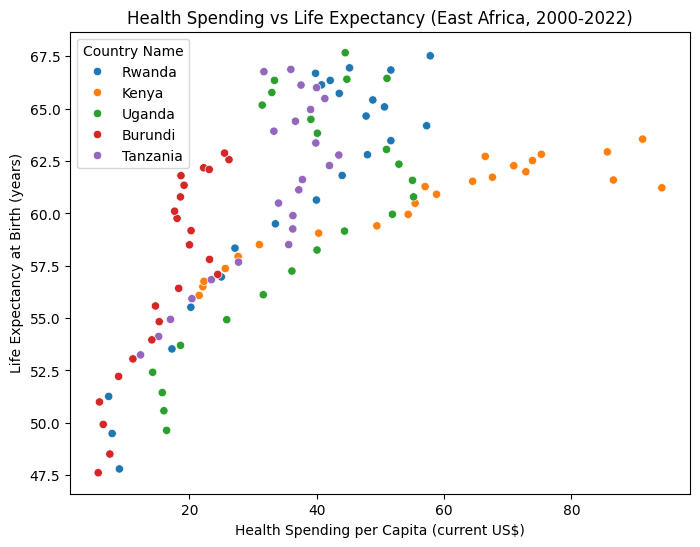

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=merged, x="HealthSpending", y="LifeExpectancy", hue="Country Name")
plt.title("Health Spending vs Life Expectancy (East Africa, 2000-2022)")
plt.xlabel("Health Spending per Capita (current US$)")
plt.ylabel("Life Expectancy at Birth (years)")
plt.show()

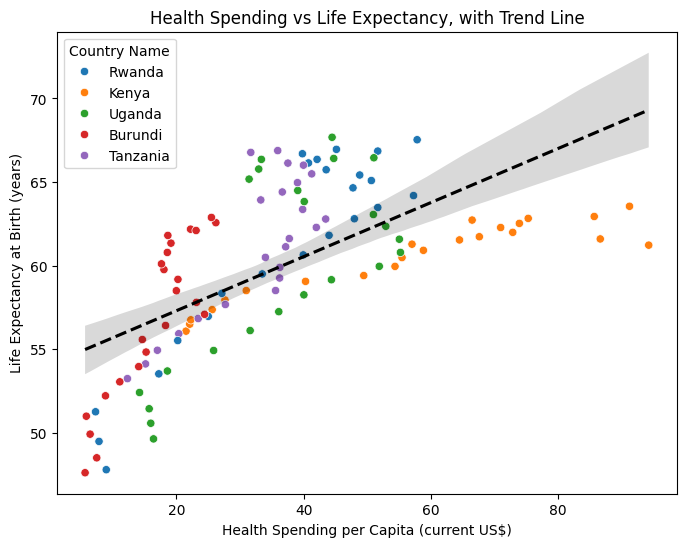

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=merged, x="HealthSpending", y="LifeExpectancy", hue="Country Name")
sns.regplot(data=merged, x="HealthSpending", y="LifeExpectancy", scatter=False, color="black", line_kws={"linestyle":"--"})
plt.title("Health Spending vs Life Expectancy, with Trend Line")
plt.xlabel("Health Spending per Capita (current US$)")
plt.ylabel("Life Expectancy at Birth (years)")
plt.show()

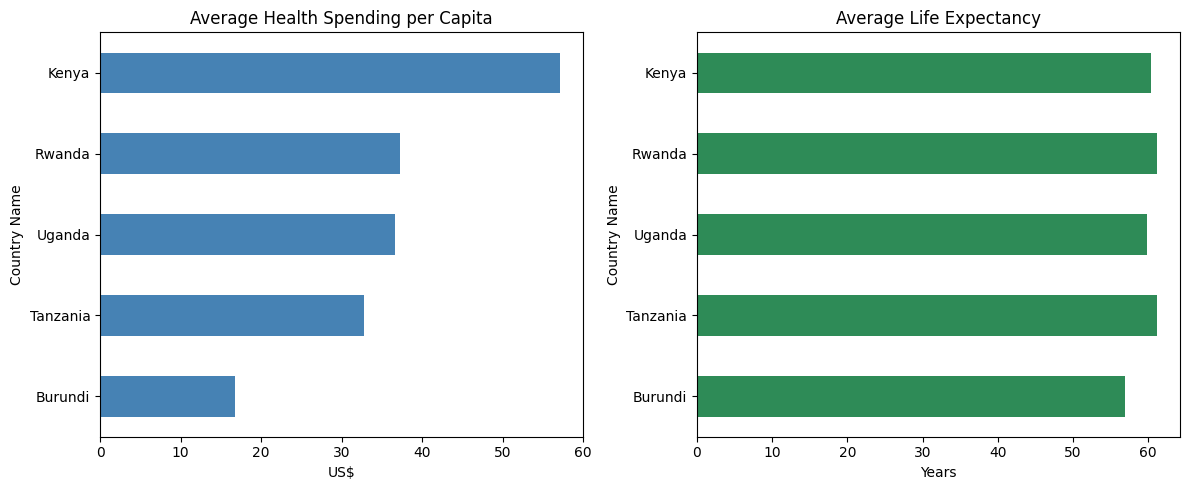

In [19]:
avg_by_country = merged.groupby("Country Name")[["HealthSpending", "LifeExpectancy"]].mean().sort_values("HealthSpending")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

avg_by_country["HealthSpending"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Average Health Spending per Capita")
axes[0].set_xlabel("US$")

avg_by_country["LifeExpectancy"].plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Average Life Expectancy")
axes[1].set_xlabel("Years")

plt.tight_layout()
plt.show()

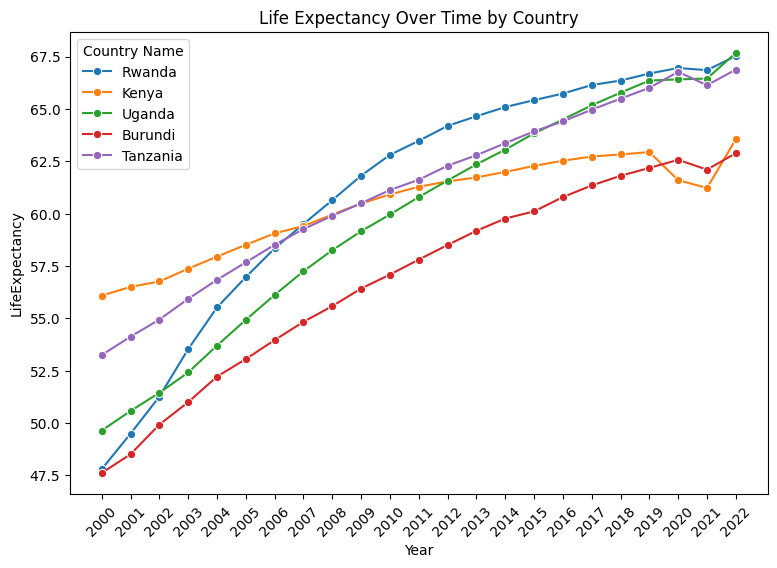

In [20]:
plt.figure(figsize=(9,6))
sns.lineplot(data=merged, x="Year", y="LifeExpectancy", hue="Country Name", marker="o")
plt.xticks(rotation=45)
plt.title("Life Expectancy Over Time by Country")
plt.show()

In [17]:
import statsmodels.api as sm

X = sm.add_constant(merged["HealthSpending"])
y = merged["LifeExpectancy"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         LifeExpectancy   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     77.11
Date:                Tue, 08 Sep 2026   Prob (F-statistic):           1.99e-14
Time:                        15:47:52   Log-Likelihood:                -317.01
No. Observations:                 115   AIC:                             638.0
Df Residuals:                     113   BIC:                             643.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             54.0640      0.756     71.

## Findings

### 1. Health spending is significantly associated with life expectancy
Across all five countries and years studied (2000–2022), higher per-capita health 
spending was significantly associated with higher life expectancy (p < 0.001). Each 
additional $10 in health spending per capita was associated with an increase of 
approximately 1.6 years in life expectancy. However, spending alone explained only 
41% of the variation in outcomes (R² = 0.406) — meaning more than half of the 
differences in life expectancy come from factors outside this model, such as 
nutrition, disease burden, and healthcare quality.

### 2. Kenya is a striking outlier
Despite spending the most on health per capita of the five countries, at times more 
than double its neighbors, Kenya's life expectancy gains plateau earlier and lower 
than expected. Rwanda and Uganda, spending far less, show steeper early returns: 
small increases in spending correspond to larger jumps in life expectancy at the 
lower end of the spending range. This suggests Kenya's additional health spending 
may not be translating into outcomes as efficiently as in lower-spending countries — 
worth investigating further (e.g., whether spending is reaching primary/preventive 
care versus higher-cost interventions).

### 3. Diminishing returns pattern
The relationship between spending and life expectancy is not linear — it appears to 
flatten out at higher spending levels. This "diminishing returns" pattern is common 
in health economics: early investment yields large gains, but returns shrink as 
spending increases, especially once basic care access is achieved.

### 4. Rwanda shows the most efficient improvement
Rwanda combines relatively low health spending with strong, steadily improving life 
expectancy — closing much of the early gap with higher-spending countries by 2022. 
This positions Rwanda as a potential model

## Recommendations

1. **Investigate Kenya's spending allocation.** Given that high spending hasn't 
   translated into proportionally higher life expectancy, a follow-up study should 
   break down *where* Kenya's health budget goes (primary care, hospitals, 
   administration) to identify inefficiencies that other countries could learn from.

2. **Study Rwanda's model as a low-cost, high-impact case.** Rwanda's steep 
   improvement curve at lower spending levels suggests effective use of limited 
   resources — likely through community health worker programs and preventive care. 
   This model may be worth documenting and sharing as a regional benchmark.

3. **Shift focus toward efficiency, not just volume, of spending.** Since spending 
   alone explains only 41% of the variation in outcomes, health policy conversations 
   in the region should weigh *how* money is spent (preventive vs. curative, rural 
   vs. urban access) alongside *how much*.

4. **Extend this analysis with elderly-specific indicators.** This study used general 
   life expectancy at birth as a proxy. A stronger next step would incorporate 
   indicators specific to older adults — e.g., healthy life expectancy at 60, 
   NCD (non-communicable disease) prevalence, or elderly healthcare access surveys — 
   to speak more directly to the original question about elderly healthcare comfort 
   and access.

## Limitations
This analysis is based on country-level aggregate data, which can mask within-country 
disparities (urban vs. rural, income levels). It also does not control for other 
factors known to affect life expectancy, such as education, sanitation, or disease 
burden. Correlation shown here does not imply causation — higher spending and better 
outcomes may both result from broader factors like governance or economic development.